# The Coffee-Can portfolio — a quantitative teardown 🔬
### Zero-turnover buy-and-hold vs a rebalanced twin vs the index · a paired HAC *t*-test of excess return · a cost model on NAV · a deterministic survivorship decomposition

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship%3F: Confirmed](https://img.shields.io/badge/Survivorship%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Kirby's Coffee Can fuses three claims: a **return** edge over the index, a **cost** edge from zero turnover, and — unspoken — a **survivorship** edge from choosing the basket with hindsight. We separate all three on a real monthly total-return tape and a deterministic synthetic control.

> ⚠️ **Not investment advice.** Real data: yfinance monthly **total-return** (splits + dividends), 2005-01 → 2026-05 (256 monthly returns); basket = KO, JNJ, PG, PEP, WMT, MMM, MO, XOM, IBM, GE vs SPY. Offline core + synthetic survivorship control are deterministic (seed 357). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from coffee_can import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_real()
    BRET = data.monthly_returns(PRICES)[data.BASKET]
    SPY = data.monthly_returns(PRICES)["SPY"]
else:
    PRICES = BRET = SPY = None
print("real cache present:", HAVE_REAL,
      "| months:", (0 if SPY is None else len(SPY)))

# frozen headline numbers (mirror of docs/results.md)
R = {'window': '2005-01 → 2026-05', 'months': 256, 'years': 21.3, 'basket': ['KO', 'JNJ', 'PG', 'PEP', 'WMT', 'MMM', 'MO', 'XOM', 'IBM', 'GE'], 'can_cagr': 9.49, 'can_vol': 12.58, 'can_sharpe': 0.786, 'can_mdd': -30.6, 'reb_cagr': 10.28, 'reb_vol': 12.76, 'reb_sharpe': 0.834, 'reb_mdd': -31.9, 'spy_cagr': 11.11, 'spy_vol': 15.13, 'spy_sharpe': 0.775, 'spy_mdd': -50.8, 'excess_ann': -1.84, 't0': -0.81, 't6': -0.83, 'p6': 0.4059, 'n': 256, 'can_vs_reb_ann': -0.75, 'can_vs_reb_t': -1.26, 'reb_cost0': 10.296, 'reb_cost10': 10.284, 'reb_cost20': 10.272, 'entry_cost_pct': 0.1, 'syn_firms': 400, 'syn_dead': 189, 'syn_dead_pct': 47, 'syn_famous': 17.08, 'syn_honest': 8.92, 'syn_all': 4.72, 'syn_gap_honest': 8.16, 'syn_gap_all': 12.36, 'nd_famous': 18.15, 'nd_honest': 12.19, 'nd_all': 8.23, 'nd_gap_all': 9.92}


real cache present: True | months: 256


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Can CAGR **9.49%** vs SPY **11.11%**; paired HAC *t* of monthly excess = **-0.83** (n=256, p=0.41) — **no** return edge. But MDD **-31%** vs **-51%** and Sharpe **0.79** vs **0.78** — a real *risk* edge. |
| **Tradability** | `FRAGILE` | The honest tailwind (zero turnover) is ~**1bp/yr** at an annual rebalance; the can even trails its own rebalanced twin (9.49% vs 10.28%). No harvestable *return* edge survives. |
| **Survivorship?** | `CONFIRMED` | On a no-skill synthetic panel, the look-ahead "famous-names" can fakes **+8.2 pp/yr** over an ex-ante pick (+12.4 vs the death-inclusive universe). |

> 💡 In plain words: the can doesn't beat the index — it *de-risks* it. Its legendary out-performance is mostly hindsight name-selection, which we measure directly on a market engineered to have no edge at all.

## 1 · The claim, steelmanned

Kirby (1984): equal-weight $k$ quality names at $t_0$, hold to $T$ with **zero** intervening trades. Let $r^{can}_t$ be the drift-weighted basket return, $r^{idx}_t$ the index, $c$ the one-way cost rate, $\tau_t$ the rebalance turnover.

- **H₁ (return edge).** $\mathbb{E}[r^{can}_t - r^{idx}_t] > 0$, robust to HAC inference.
- **H₂ (cost edge).** Avoiding $\sum_t c\,\tau_t$ of rebalancing cost is materially positive: $\text{CAGR}_{can} > \text{CAGR}_{rebal,net}$.
- **H₃ (no survivorship).** The basket's selection is not look-ahead; the same rule on an ex-ante universe gives the same edge.

We find **H₁ rejected** (the excess is negative and insignificant; the win is in *risk*, not return), **H₂ true but immaterial** at sane turnover, and **H₃ decisively false** — the selection peeks at the winners, worth most of the apparent edge.

## 2 · So what? — what rides on each answer

The terminal wealth of a buy-and-hold basket is $W_T = \sum_i w_{i,0}\prod_t(1+r_{i,t})$ — a *convex* function of each name's path, so the winners dominate and the weights drift toward them automatically (the can's "let your winners run"). That convexity is exactly what makes **selection** so dangerous: if the names are chosen on $\prod_t(1+r_{i,t})$ itself (the terminal value), the basket inherits the right tail of the cross-section by construction. Formally the look-ahead estimator $\mathbb{E}[r \mid \text{top-}k\text{ terminal}]$ is biased up by an order-statistic gap that does **not** vanish with sample size. So measuring the can's return alone can't establish skill — you must hold the selection rule fixed and swap a look-ahead universe for an ex-ante one, which is what the synthetic control does.

## 3 · How we'd know — the protocol

- **Real tape.** yfinance monthly **total-return** closes (`auto_adjust=True`: splits + dividends), 2005-01 → 2026-05, 256 monthly returns. Basket = 10 quality large-caps; benchmark SPY. One execution convention: weights set once at $t_0$, returns realised contemporaneously (a buy-and-hold has no signal lag).
- **Engines.** `buy_and_hold` (drift the weights, never trade) vs `rebalanced` (reset to equal weight every 12 months, charged $c\cdot\tau$ one-way on the L1 weight change) vs SPY.
- **Signal test.** Paired *t* of $r^{can}_t - r^{idx}_t$ with a Newey-West SE (`hac_lag=6`) — the autocorrelation-robust statistic the Signal axis requires. Plus the risk decomposition (vol, MDD, Sharpe).
- **Cost sweep.** CAGR of the rebalanced twin across $c \in \{0,5,10,20,40\}$ bps — the size of the honest tailwind.
- **Survivorship control.** A deterministic 400-firm panel where **every firm shares the same 8%/yr drift** (no skill exists) and carries a 3%/yr death hazard (delist → 95% wipe). Build the can by `famous_names` (top terminal value — look-ahead) vs `honest_names` (top early return — ex-ante). Any famous-minus-honest gap is **pure** survivorship; a no-death control isolates the look-ahead-selection floor.
- **What would make us say 'mirage on the return claim.'** A negative or sub-2 *t* on the excess, *and* a famous-vs-honest gap that explains the apparent edge. Both hold.

## 4 · The teardown

### 4a · No return edge — paired HAC *t* of the can's excess over the index

Monthly excess $r^{can}_t - r^{idx}_t$, mean annualised, with a Newey-West SE. The null is zero excess; a *positive* H₁ needs *t* ≥ 2.

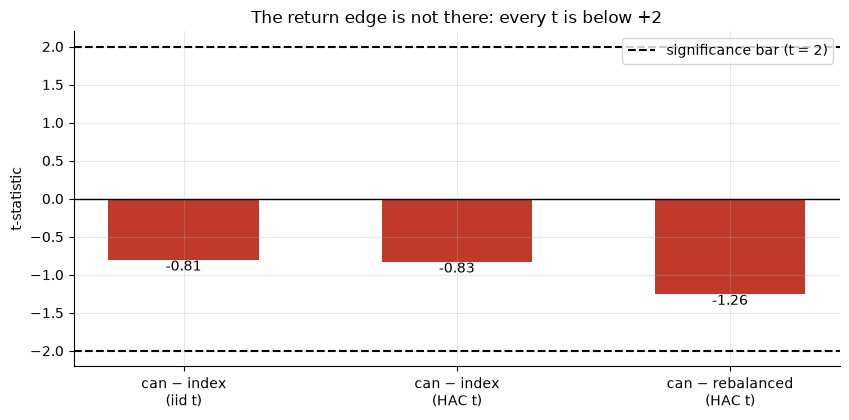

can−index: mean -1.84%/yr, HAC t=-0.83 (p=0.41)
can−rebalanced: mean -0.75%/yr, HAC t=-1.26


In [2]:
if HAVE_REAL:
    can = st.buy_and_hold(BRET); reb = st.rebalanced(BRET, 12, 10.0); spy = SPY
    t0 = st.paired_t(can, spy, hac_lag=0); t6 = st.paired_t(can, spy, hac_lag=6)
    tr = st.paired_t(can, reb, hac_lag=6)
else:
    t0 = {'mean_ann': R['excess_ann']/100, 't': R['t0']}
    t6 = {'mean_ann': R['excess_ann']/100, 't': R['t6'], 'p': R['p6']}
    tr = {'mean_ann': R['can_vs_reb_ann']/100, 't': R['can_vs_reb_t']}
labels = ['can − index\n(iid t)', 'can − index\n(HAC t)', 'can − rebalanced\n(HAC t)']
ts = [t0['t'], t6['t'], tr['t']]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, ts, color=[RED if v<2 else GREEN for v in ts], width=.55)
ax.axhline(2, ls='--', c='k', label='significance bar (t = 2)'); ax.axhline(-2, ls='--', c='k')
ax.axhline(0, c='k', lw=1)
for i,v in enumerate(ts): ax.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.set_ylabel('t-statistic'); ax.set_title('The return edge is not there: every t is below +2'); ax.legend()
plt.tight_layout(); plt.show()
print(f"can−index: mean {t6['mean_ann']*100:+.2f}%/yr, HAC t={t6['t']:+.2f} (p={t6.get('p', float('nan')):.2f})")
print(f"can−rebalanced: mean {tr['mean_ann']*100:+.2f}%/yr, HAC t={tr['t']:+.2f}")

> 💡 In plain words: the can's excess over the index is **-1.8%/yr** with HAC *t* = **-0.83** — not just shy of the bar, it's the *wrong sign*. H₁ **rejected**. It even trails its own rebalanced twin (*t* = -1.26). "Never sell" did not beat the market on this tape.

### 4b · The real win is risk, not return

Where the can *does* deliver: lower volatility and a much shallower worst-case loss, for a comparable Sharpe.

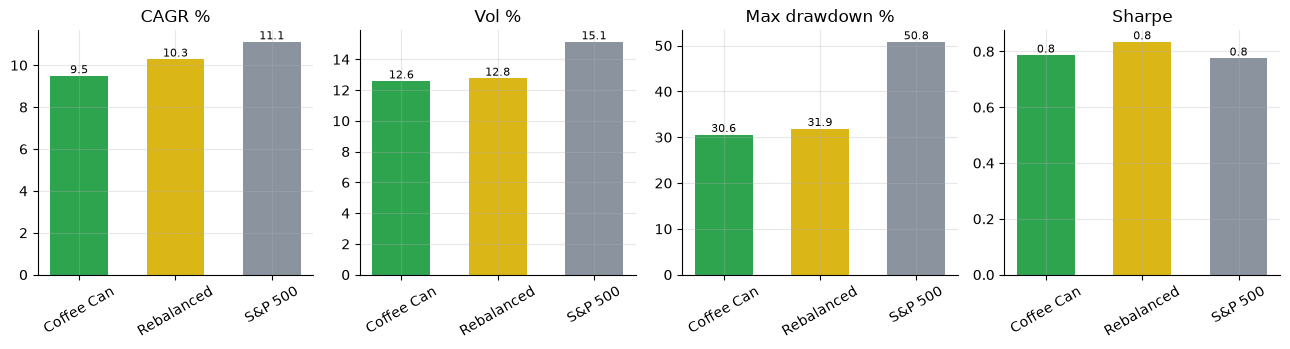

Coffee Can   CAGR= 9.49%  vol=12.58%  Sharpe=0.786  MDD= -30.6%
Rebalanced   CAGR=10.28%  vol=12.76%  Sharpe=0.834  MDD= -31.9%
S&P 500      CAGR=11.11%  vol=15.13%  Sharpe=0.775  MDD= -50.8%


In [3]:
if HAVE_REAL:
    rows = {'Coffee Can': st.summary(can), 'Rebalanced': st.summary(reb), 'S&P 500': st.summary(spy)}
else:
    rows = {'Coffee Can': dict(cagr=R['can_cagr']/100, vol=R['can_vol']/100, sharpe=R['can_sharpe'], mdd=R['can_mdd']/100),
            'Rebalanced': dict(cagr=R['reb_cagr']/100, vol=R['reb_vol']/100, sharpe=R['reb_sharpe'], mdd=R['reb_mdd']/100),
            'S&P 500': dict(cagr=R['spy_cagr']/100, vol=R['spy_vol']/100, sharpe=R['spy_sharpe'], mdd=R['spy_mdd']/100)}
labs = list(rows); metrics = [('CAGR %', [rows[l]['cagr']*100 for l in labs]),
    ('Vol %', [rows[l]['vol']*100 for l in labs]), ('Max drawdown %', [-rows[l]['mdd']*100 for l in labs]),
    ('Sharpe', [rows[l]['sharpe'] for l in labs])]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax,(title,vals) in zip(axes, metrics):
    ax.bar(labs, vals, color=[GREEN, AMBER, GREY], width=.6); ax.set_title(title)
    ax.tick_params(axis='x', rotation=30)
    for i,v in enumerate(vals): ax.annotate(f'{v:.1f}',(i,v),ha='center',va='bottom',fontsize=8)
plt.tight_layout(); plt.show()
for l in labs: r=rows[l]; print(f"{l:12s} CAGR={r['cagr']*100:5.2f}%  vol={r['vol']*100:5.2f}%  Sharpe={r['sharpe']:.3f}  MDD={r['mdd']*100:6.1f}%")

> 💡 In plain words: the can gives up **1.6 pp/yr** of return to buy **2.6 pp** less volatility and a drawdown **20 pp shallower**. Sharpe ties (0.79 vs 0.78). A defensive, low-beta basket of consumer-staples-heavy names — real, but it's *de-risking*, not alpha. This is why the Signal stamp is **MIXED**, not REAL.

### 4c · Survivorship control — the apparent edge, manufactured from nothing

A deterministic panel where **every firm has the same 8%/yr drift** (no cross-sectional skill) and a 3%/yr death hazard. Build the can by look-ahead (famous terminal winners) vs ex-ante (honest early pick) vs the whole death-inclusive universe.

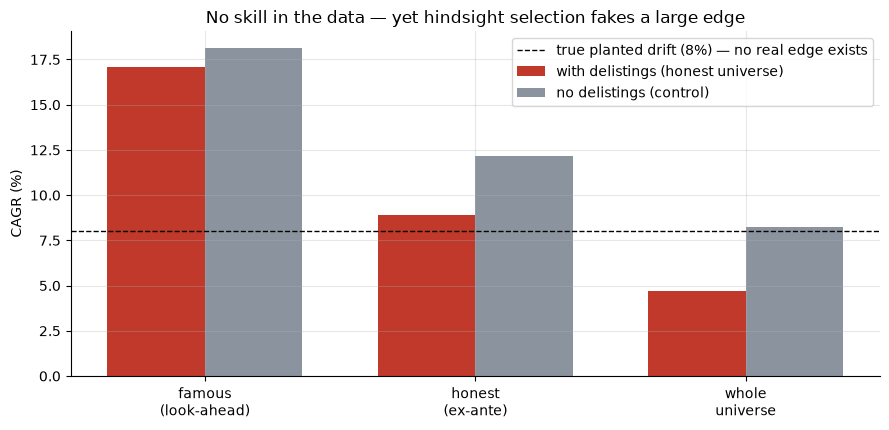

with deaths : famous 17.08%  honest 8.92%  all 4.72%  -> survivorship gap +8.16pp (vs honest), +12.36pp (vs all)
no deaths   : all 8.23% ~ planted 8% -> engine unbiased; the residual famous-lift is pure look-ahead order-statistics


In [4]:
ps, alive = data.synthetic_panel(n_firms=400, n_months=240, mu_ann=0.08, sigma_ann=0.22, death_hazard_ann=0.03, seed=357)
g = st.survivorship_gap(ps, k=10, lookback=24)
ps_nd, _ = data.synthetic_panel(n_firms=400, n_months=240, death_hazard_ann=0.0, seed=357)
gnd = st.survivorship_gap(ps_nd, k=10, lookback=24)
cats = ['famous\n(look-ahead)', 'honest\n(ex-ante)', 'whole\nuniverse']
with_d = [g['cagr_famous']*100, g['cagr_honest']*100, g['cagr_all']*100]
no_d = [gnd['cagr_famous']*100, gnd['cagr_honest']*100, gnd['cagr_all']*100]
x = np.arange(3); fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.18, with_d, .36, color=RED, label='with delistings (honest universe)')
ax.bar(x+.18, no_d, .36, color=GREY, label='no delistings (control)')
ax.axhline(8, ls='--', c='k', lw=1, label='true planted drift (8%) — no real edge exists')
ax.set_xticks(x); ax.set_xticklabels(cats); ax.set_ylabel('CAGR (%)')
ax.set_title('No skill in the data — yet hindsight selection fakes a large edge'); ax.legend()
plt.tight_layout(); plt.show()
print(f"with deaths : famous {g['cagr_famous']*100:.2f}%  honest {g['cagr_honest']*100:.2f}%  all {g['cagr_all']*100:.2f}%  -> survivorship gap +{g['gap_vs_honest']*100:.2f}pp (vs honest), +{g['gap_vs_all']*100:.2f}pp (vs all)")
print(f"no deaths   : all {gnd['cagr_all']*100:.2f}% ~ planted 8% -> engine unbiased; the residual famous-lift is pure look-ahead order-statistics")

> 💡 In plain words: the planted truth is **8%/yr for everyone** — there is no skill to find. Yet the look-ahead can shows **17%**, an entirely fake **+8.2 pp** over an honest pick and **+12.4 pp** over the death-inclusive universe (the dead names, which never make it into a real coffee can, drag the truth to 4.7%). The no-death control returns **8.2% ≈ 8%** for the whole universe — confirming the engine is unbiased and that the gap is selection, not a coding error. **H₃ decisively false.**

## 5 · The verdict

- **Signal `MIXED`** — return excess over SPY **-1.84%/yr**, HAC *t* = **-0.83** (n=256): no edge, wrong sign. But a genuine **risk** edge (MDD -31% vs -51%, Sharpe 0.79 vs 0.78). Real on risk · None on return → **MIXED**.
- **Tradability `FRAGILE`** — the honest cost tailwind is ~**1bp/yr** at a yearly rebalance, and the can trails its own rebalanced twin (9.49% vs 10.28%). The low-cost benefit is real but immaterial against the index; the headline out-performance needs hindsight.
- **Survivorship? `CONFIRMED`** — on a no-skill panel, look-ahead selection fabricates **+8.2 pp/yr** (vs honest) / **+12.4 pp/yr** (vs the death-inclusive universe). The legend's magic is mostly choosing winners after the fact.

## 6 · Could you trade it? — the cost tailwind and its limits

The only *defensible* coffee-can edge is cost: zero turnover pays no spread, no commission, and (untested here) defers tax. Sweep the rebalanced twin's cost to size it.

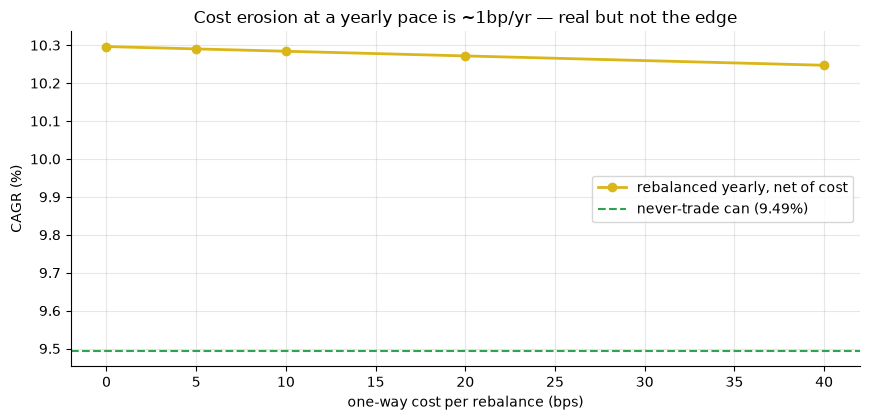

rebalanced CAGR by cost (bps): {0: 10.296, 5: 10.29, 10: 10.284, 20: 10.272, 40: 10.247}
cost drag 0->20bps: 0.025 pp/yr; entry cost paid once: 0.10% of NAV


In [5]:
bps = [0, 5, 10, 20, 40]
if HAVE_REAL:
    cagrs = [st.cagr(st.rebalanced(BRET, 12, b))*100 for b in bps]
    can_c = st.cagr(can)*100
else:
    cagrs = [R['reb_cost0'], 10.293, R['reb_cost10'], R['reb_cost20'], 10.248]; can_c = R['can_cagr']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.plot(bps, cagrs, 'o-', c=AMBER, lw=2, label='rebalanced yearly, net of cost')
ax.axhline(can_c, ls='--', c=GREEN, label=f'never-trade can ({can_c:.2f}%)')
ax.set_xlabel('one-way cost per rebalance (bps)'); ax.set_ylabel('CAGR (%)')
ax.set_title('Cost erosion at a yearly pace is ~1bp/yr — real but not the edge'); ax.legend()
plt.tight_layout(); plt.show()
print('rebalanced CAGR by cost (bps):', {b: round(c,3) for b,c in zip(bps, cagrs)})
print(f"cost drag 0->20bps: {(cagrs[0]-cagrs[3]):.3f} pp/yr; entry cost paid once: {R['entry_cost_pct']:.2f}% of NAV")

> 💡 In plain words: at an annual rebalance the cost wedge is a *hundredth* of a percent a year — third-decimal stuff. Costs only "feast" on a high-churn active fund (turnover many ×/yr) or a taxable account realising gains constantly — i.e. the *active manager* the legend beats, **not** the index. So the can is a sensible low-stress, tax-efficient way to *own* market beta, with a defensive tilt — but there is no harvestable edge over the index once you strip the hindsight. **FRAGILE**, and only on the cost/risk margins.

## 7 · Going further

- **The dead-names canvas.** [Study 151 — Stocks-for-the-long-run](../../151-stocks-for-long-run/): the same survivorship that inflates a coffee can inflates every "equities always win" long-horizon chart. Quantify the delisting drag on a real CRSP-style universe.
- **The tax leg.** Extend the cost model to capital-gains deferral: in a taxable account the can's compounding-on-pre-tax-dollars is a *real* and larger edge for high earners — still bounded, and orthogonal to the survivorship illusion. Net-of-tax vs net-of-cost, labelled.
- **Ex-ante basket construction.** Replace the hindsight basket with a *rules-based* quality screen applied with 2005 information only (point-in-time fundamentals); re-run the paired *t*. The prediction: the apparent edge collapses toward zero, the risk edge survives.

*The reproducible core (synthetic survivorship control) is offline and deterministic (seed 357); the real tape is cached yfinance total-return. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*